In [12]:
from GradientGang.Pipeline.DataLoader.DataLoader import DataModule

params = {
    'data_dir': "../dataset/PirateProcessed/",
    'train_file_name': "pirate_pain_train.csv",
    'train_file_name_labels': "pirate_pain_train_labels.csv",
    'test_file_name': "pirate_pain_test.csv",
    'batch_size': 32,
    'num_workers': 0,
    'val_split': 0.1,
    'shuffle': True,
}

dataLoader = DataModule(params=params)
dataLoader.setup(stage='fit', includeTestInTrain=False)

trainLoader = dataLoader.train_dataloader()
valLoader = dataLoader.val_dataloader()

dataLoader.setup(stage='test')
testLoader = dataLoader.test_dataloader()

In [13]:
for batch in trainLoader:
    (time_series, global_features), labels = batch
    print("Train Batch - Time Series Shape:", time_series.shape)
    print("Train Batch - Global Features Shape:", global_features.shape)
    print("Train Batch - Labels Shape:", labels.shape)
    break

Train Batch - Time Series Shape: torch.Size([32, 34, 160])
Train Batch - Global Features Shape: torch.Size([32, 1])
Train Batch - Labels Shape: torch.Size([32])


In [14]:
# Check label values to understand the data
import torch
all_labels_check = []
for batch in trainLoader:
    (time_series, global_features), labels = batch
    all_labels_check.extend(labels.numpy())

print("Unique labels in training set:", set(all_labels_check))
print("Min label:", min(all_labels_check))
print("Max label:", max(all_labels_check))
print("Label counts:", {label: all_labels_check.count(label) for label in set(all_labels_check)})


Unique labels in training set: {np.int64(0), np.int64(1), np.int64(2)}
Min label: 0
Max label: 2
Label counts: {np.int64(0): 467, np.int64(1): 82, np.int64(2): 46}


In [15]:
from GradientGang.Pipeline.Architectures.LightningAutoencoder import LightningAutoencoder
from torchsummary import summary

In [16]:
# Reload the modules to get the latest changes
import importlib
import GradientGang.Pipeline.Architectures.LightningAutoencoder
import GradientGang.Pipeline.Architectures.Decoder
import GradientGang.Pipeline.Architectures.Direct
importlib.reload(GradientGang.Pipeline.Architectures.Decoder)
importlib.reload(GradientGang.Pipeline.Architectures.LightningAutoencoder)
importlib.reload(GradientGang.Pipeline.Architectures.Direct)
from GradientGang.Pipeline.Architectures.Direct import Direct

print("✓ Modules reloaded successfully")


✓ Modules reloaded successfully


In [17]:
# Create a direct architecture configuration
# Direct architecture: Encoder (GRU) -> FeedForward for classification (no decoder)
architectureDirect = {
    "LearningRate": 0.001,
    "Patience": 5,
    "RegularizationWeight": 0.1,
    "EncoderParams": {
        "activation_function": "GELU",
        "layer_type": [
            {
                "name": "GRU",
                "params": {
                    "input_size": 34,
                    "hidden_size": 128,
                    "num_layers": 2,
                    "bias": True,
                    "batch_first": True,
                    "dropout": 0.2,
                    "bidirectional": True  # Output will be hidden_size * 2 = 256
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 256,  # 128 * 2 because bidirectional=True
                    "out_features": 128,
                    "bias": True,
                }
            }
        ]
    },
    "GlobalFFEncoderParams": {
        "activation_function": "LeakyReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 1,
                    "out_features": 1,
                    "bias": True,
                }
            },
        ]
    },
    "FeedForwardParams": {
        "activation_function": "ReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 129,  # 128 (encoder) + 1 (global feature)
                    "out_features": 64,
                    "bias": True,
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 64,
                    "out_features": 32,
                    "bias": True,
                }
            }
        ]
    },
    "OutputDim": 3  # Number of classes
}

# Create new direct model with the configuration
autoencoder_fixed = Direct(architectureDirect)

In [18]:
# Test the direct architecture to verify it works correctly
import torch
with torch.no_grad():
    test_batch = next(iter(trainLoader))
    (test_time_series, test_global_features), test_labels = test_batch
    print("✓ Input time series shape:", test_time_series.shape)
    print("✓ Input global features shape:", test_global_features.shape)
    print("✓ Input labels shape:", test_labels.shape)
    
    # Direct architecture only returns predictions (no decoder outputs)
    predictions = autoencoder_fixed((test_time_series, test_global_features))
    
    print("\n✓ Output predictions shape:", predictions.shape)
    print("✓ Expected output shape: (batch_size, num_classes) = ({}, 3)".format(test_time_series.shape[0]))
    
    print("\n" + "="*50)
    print("ARCHITECTURE VERIFICATION:")
    print("="*50)
    print(f"Predictions shape: {predictions.shape}")
    print(f"Expected: ({test_time_series.shape[0]}, 3)")
    print(f"Match? {'✅ YES' if predictions.shape == (test_time_series.shape[0], 3) else '❌ NO'}")
    
    # Test prediction output
    print(f"\nPredicted classes: {predictions.argmax(dim=1)[:10]}")
    print(f"True labels: {test_labels[:10]}")


✓ Input time series shape: torch.Size([32, 34, 160])
✓ Input global features shape: torch.Size([32, 1])
✓ Input labels shape: torch.Size([32])

✓ Output predictions shape: torch.Size([32, 3])
✓ Expected output shape: (batch_size, num_classes) = (32, 3)

ARCHITECTURE VERIFICATION:
Predictions shape: torch.Size([32, 3])
Expected: (32, 3)
Match? ✅ YES

Predicted classes: tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
True labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 2])


In [20]:
from pytorch_lightning import Trainer

trainer = Trainer(max_epochs=10, enable_progress_bar=True,)
trainer.fit(autoencoder_fixed, trainLoader, valLoader)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name             | Type              | Params | Mode 
---------------------------------------------------------------
0 | encoder          | Encoder           | 455 K  | train
1 | globalff_encoder | FeedForward       | 2      | train
2 | feedforward      | FeedForward       | 10.5 K | train
3 | val_f1           | MulticlassF1Score | 0      | train
---------------------------------------------------------------
465 K     Trainable params
0         Non-trainable params
465 K     Total params
1.863     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 19/19 [00:06<00:00,  3.00it/s, v_num=8]          

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 19/19 [00:06<00:00,  3.00it/s, v_num=8]


In [ ]:
# Compute F1 score on val set using the Direct architecture
from torchmetrics import F1Score
import torch

all_preds = []
all_labels = []
for batch in valLoader:
    x, labels = batch
    with torch.no_grad():
        preds = autoencoder_fixed(x)  # Direct returns predictions directly (not a tuple)
    all_preds.extend(preds.argmax(dim=1).cpu().numpy())
    all_labels.extend(labels)

print(all_preds)
print(all_labels)

f1 = F1Score(task="multiclass", num_classes=3, average='macro')
f1 = f1(torch.tensor(all_preds), torch.tensor(all_labels))
print("Validation F1 Score:", f1)


[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0)]
[tensor(0), tensor(0), tensor(2), tensor(0), tensor(2), tensor(0), tensor(0), tensor(0), tensor(1), tensor(0), tensor(0), tensor(0), tensor(1

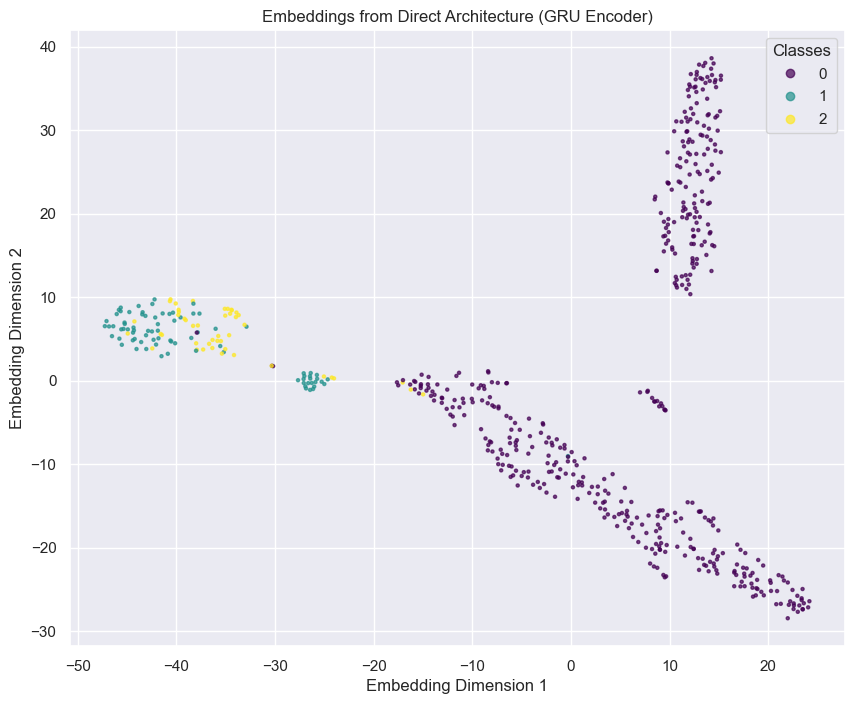

In [ ]:
# Plot embeddings using the Direct architecture
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import torch
sns.set_theme()

embeddings = []
labels_list = []
for batch in trainLoader:
    (time_series, global_features), labels = batch
    with torch.no_grad():
        # Direct architecture: encode time series through the encoder
        embedding = autoencoder_fixed.encoder(time_series)
    embeddings.append(embedding.cpu())
    labels_list.append(labels)

embeddings = torch.cat(embeddings, dim=0).numpy()
labels_list = torch.cat(labels_list, dim=0).numpy()

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_list, alpha=0.7, cmap='viridis', s=5)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('Embeddings from Direct Architecture (GRU Encoder)')
plt.xlabel('Embedding Dimension 1')
plt.ylabel('Embedding Dimension 2')
plt.show()


In [27]:
# Reload SubmissionGenerator to get the latest changes
import importlib
import GradientGang.Pipeline.SubmissionGenerator.SubmissionGenerator
importlib.reload(GradientGang.Pipeline.SubmissionGenerator.SubmissionGenerator)
from GradientGang.Pipeline.SubmissionGenerator.SubmissionGenerator import SubmissionGenerator

submission_generator = SubmissionGenerator(
    model=autoencoder_fixed,
    dataloader=testLoader,
    label_mapping={0: 'no_pain', 1: 'low_pain', 2: 'high_pain'},
)

predictions = submission_generator.generate_predictions()
print("Sample Predictions:", predictions[:10])

Sample Predictions: tensor([0, 0, 2, 0, 0, 1, 0, 0, 0, 0])


In [29]:
submission_generator.generate_submission(
    output_path="../Submissions/submission_direct_architecture.csv"
)

,sample_index,label
0,000,no_pain
1,001,no_pain
2,002,high_pain
3,003,no_pain
4,004,no_pain
...,...,...
1319,1319,no_pain
1320,1320,no_pain
1321,1321,no_pain
1322,1322,no_pain
